In [124]:
!pip -q install biopython pandas numpy scipy matplotlib
!apt-get -qq install clustalo

from Bio import AlignIO
from collections import Counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu
from google.colab import files

In [125]:
uploaded = files.upload()

Saving TP53_multispecies.fasta to TP53_multispecies (5).fasta


In [126]:
!clustalo -i TP53_multispecies.fasta -o TP53_MSA.fasta --force --outfmt fasta

In [127]:
!ls

 Figure1_Boxplot.png	    'TP53_multispecies (1).fasta'
 Figure2_Scatter.png	    'TP53_multispecies (2).fasta'
 sample_data		    'TP53_multispecies (3).fasta'
 TP53_hotspot_analysis.csv  'TP53_multispecies (4).fasta'
 TP53_MSA_1.fasta	    'TP53_multispecies (5).fasta'
'TP53_MSA (1).fasta'	     TP53_multispecies.fasta
 TP53_MSA.fasta


In [128]:
alignment = AlignIO.read("TP53_MSA.fasta", "fasta")

print("Sequences:", len(alignment))
print("Alignment length:", alignment.get_alignment_length())

Sequences: 12
Alignment length: 417


In [129]:
def conservation_score(column):
    counts = Counter(column.replace("-", ""))
    if not counts:
        return 0
    return max(counts.values()) / sum(counts.values())

scores = []
for i in range(alignment.get_alignment_length()):
    col = alignment[:, i]
    scores.append(conservation_score(col))

In [130]:
hotspots = [175, 245, 248, 249, 273, 282]

hotspot_scores = [scores[pos-1] for pos in hotspots]

non_hotspots = [i for i in range(len(scores)) if (i+1) not in hotspots]

np.random.seed(42)
sample_non = np.random.choice(non_hotspots, size=30, replace=False)
non_scores = [scores[i] for i in sample_non]

In [131]:
stat, p = mannwhitneyu(hotspot_scores, non_scores)

print("Hotspot mean:", np.mean(hotspot_scores))
print("Non-hotspot mean:", np.mean(non_scores))
print("p-value:", p)

Hotspot mean: 0.9545454545454546
Non-hotspot mean: 0.7798989898989898
p-value: 0.034040890273147974


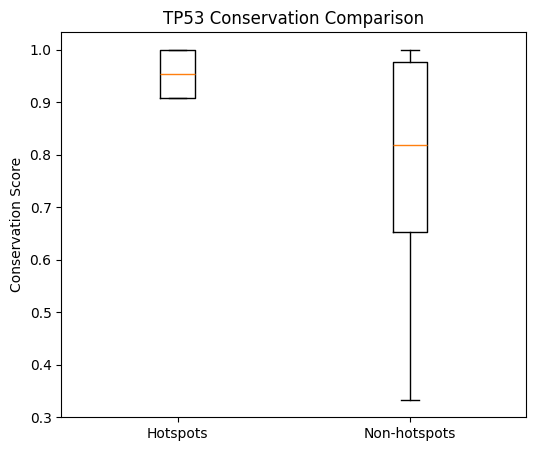

In [132]:
plt.figure(figsize=(6,5))
plt.boxplot([hotspot_scores, non_scores])
plt.xticks([1,2], ["Hotspots", "Non-hotspots"])
plt.ylabel("Conservation Score")
plt.title("TP53 Conservation Comparison")

plt.savefig("Figure1_Boxplot.png", dpi=300)
plt.show()

In [133]:
from Bio.Align import substitution_matrices
blosum62 = substitution_matrices.load("BLOSUM62")

def mutation_impact_score(wt, mut):
    if (wt, mut) in blosum62:
        return blosum62[(wt, mut)]
    elif (mut, wt) in blosum62:
        return blosum62[(mut, wt)]
    else:
        return -4

reference_seq = alignment[0].seq  # assume first = human

impact_scores = []

for pos in hotspots:
    col = alignment[:, pos-1]
    wt = reference_seq[pos-1]

    scores_mut = []
    for aa in col:
        if aa != wt and aa != '-':
            scores_mut.append(mutation_impact_score(wt, aa))

    impact_scores.append(np.mean(scores_mut) if scores_mut else 0)

In [134]:
df = pd.DataFrame({
    "Position": hotspots,
    "Conservation": hotspot_scores,
    "BLOSUM62_Impact": impact_scores
})

print(df)

   Position  Conservation  BLOSUM62_Impact
0       175      0.909091              0.0
1       245      1.000000             -4.0
2       248      0.909091             -4.0
3       249      1.000000             -4.0
4       273      1.000000             -4.0
5       282      0.909091             -4.0


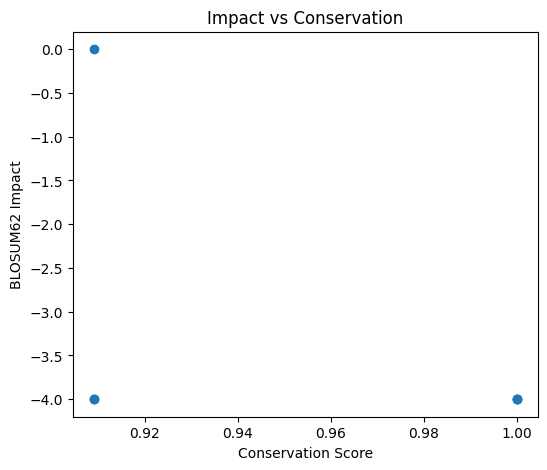

In [135]:
plt.figure(figsize=(6,5))
plt.scatter(df["Conservation"], df["BLOSUM62_Impact"])
plt.xlabel("Conservation Score")
plt.ylabel("BLOSUM62 Impact")
plt.title("Impact vs Conservation")

plt.savefig("Figure2_Scatter.png", dpi=300)
plt.show()

In [136]:
df.to_csv("TP53_hotspot_analysis.csv", index=False)

In [137]:
files.download("TP53_MSA.fasta")
files.download("TP53_hotspot_analysis.csv")
files.download("Figure1_Boxplot.png")
files.download("Figure2_Scatter.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>